In [1]:
import os
import torch
import torch.nn as nn
import torch.optim as optim
from torchvision import datasets, transforms, models
from torch.utils.data import DataLoader, random_split
import urllib.request
import tarfile

# --- 1. DATA SETUP: CUB-200-2011 ---
# Using the record link you provided to construct the direct download URL
DATA_URL = "https://data.caltech.edu/records/65de6-vp158/files/CUB_200_2011.tgz?download=1"
DATA_DIR = './CUB_DATA'

if not os.path.exists(os.path.join(DATA_DIR, 'CUB_200_2011/images')):
    if not os.path.exists(DATA_DIR): os.makedirs(DATA_DIR)
    print("Downloading CUB-200-2011 (1.1GB) from new record link...")
    urllib.request.urlretrieve(DATA_URL, os.path.join(DATA_DIR, "CUB.tgz"))
    print("Extracting archive...")
    with tarfile.open(os.path.join(DATA_DIR, "CUB.tgz"), "r:gz") as tar:
        tar.extractall(path=DATA_DIR)
    print("Setup complete.")

# --- 2. TRANSFORMS & LOADERS ---
t_cub = transforms.Compose([
    transforms.Resize(256),
    transforms.CenterCrop(224),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
])

# Points to the images subfolder within the extracted directory
full_dataset = datasets.ImageFolder(root=os.path.join(DATA_DIR, 'CUB_200_2011/images'), transform=t_cub)
train_size = int(0.8 * len(full_dataset))
train_set, test_set = random_split(full_dataset, [train_size, len(full_dataset)-train_size])

train_loader = DataLoader(train_set, batch_size=32, shuffle=True)
test_loader = DataLoader(test_set, batch_size=32, shuffle=False)

# --- 3. ARCHITECTURE: Semantic 3x3 Overlapping InstaSHAP ---
class SemanticInstaSHAP_CUB(nn.Module):
    def __init__(self):
        super().__init__()
        # 1. Frozen ResNet-18 Backbone
        resnet = models.resnet18(weights='IMAGENET1K_V1')
        self.backbone = nn.Sequential(*list(resnet.children())[:-2]) # Output: [B, 512, 7, 7]
        for p in self.backbone.parameters(): p.requires_grad = False
        
        # 2. Patch Dimensions (3x3 spatial cells = 512*3*3)
        self.patch_dim = 512 * 3 * 3
        
        # 3. Main Effects (f_i) - Deep Bottleneck
        self.main_effects = nn.Sequential(
            nn.Linear(self.patch_dim, 1024),
            nn.BatchNorm1d(1024),
            nn.ReLU(),
            nn.Linear(1024, 200) # 200 Species
        )
        
        # 4. Interaction Effects (f_ij)
        self.interaction_effects = nn.Sequential(
            nn.Linear(self.patch_dim * 2, 512),
            nn.ReLU(),
            nn.Linear(512, 200)
        )
        
        # 3x3 Adjacency (12 edges)
        self.edges = [(0,1), (1,2), (3,4), (4,5), (6,7), (7,8), # Horiz
                      (0,3), (3,6), (1,4), (4,7), (2,5), (5,8)] # Vert

    def get_semantic_patches(self, x):
        features = self.backbone(x) # [B, 512, 7, 7]
        # Sliding window: 3x3 patch on 7x7 map with stride 2
        patches = features.unfold(2, 3, 2).unfold(3, 3, 2)
        return patches.contiguous().view(x.size(0), 9, -1)

    def forward(self, x, mask):
        pts = self.get_semantic_patches(x)
        B, N, D = pts.shape
        # Main Effects
        m_out = self.main_effects(pts.view(-1, D)).view(B, N, 200)
        m_sum = (m_out * mask.unsqueeze(-1)).sum(dim=1)
        # Interaction Effects
        i_sum = torch.zeros(B, 200).cuda()
        for i, j in self.edges:
            p_mask = (mask[:, i] * mask[:, j]).unsqueeze(-1)
            i_sum += self.interaction_effects(torch.cat([pts[:, i], pts[:, j]], dim=-1)) * p_mask
        return m_sum, i_sum

# --- 4. EXPERIMENT: Ensemble Training (3 models) ---
ensemble_size = 3
ensemble_models = [SemanticInstaSHAP_CUB().cuda() for _ in range(ensemble_size)]
criterion = nn.CrossEntropyLoss()

for m_idx, model in enumerate(ensemble_models):
    print(f"\n>>> TRAINING ENSEMBLE MODEL {m_idx+1}/3")
    
    # STAGE 1: Main Effects Only (10 Epochs)
    model.interaction_effects.requires_grad_(False)
    opt1 = optim.Adam(model.main_effects.parameters(), lr=1e-3)
    for epoch in range(10):
        model.train()
        for imgs, lbls in train_loader:
            imgs, lbls = imgs.cuda(), lbls.cuda()
            mask = torch.bernoulli(torch.full((imgs.size(0), 9), 0.5)).cuda()
            mask[:, 0] = 1 # Anchor patch
            m_sum, _ = model(imgs, mask)
            loss = criterion(m_sum, lbls)
            opt1.zero_grad(); loss.backward(); opt1.step()
        print(f"Stage 1 - Epoch {epoch+1}/10 Complete")

    # STAGE 2: Interaction Learning (10 Epochs)
    model.interaction_effects.requires_grad_(True)
    opt2 = optim.Adam(model.parameters(), lr=1e-4)
    for epoch in range(10):
        model.train()
        for imgs, lbls in train_loader:
            imgs, lbls = imgs.cuda(), lbls.cuda()
            mask = torch.bernoulli(torch.full((imgs.size(0), 9), 0.5)).cuda()
            m_s, i_s = model(imgs, mask)
            # Purification Penalty (lambda=0.1)
            loss = criterion(m_s + i_s, lbls) + 0.1 * i_s.abs().mean()
            opt2.zero_grad(); loss.backward(); opt2.step()
        print(f"Stage 2 - Epoch {epoch+11}/20 Complete")

# --- 5. FINAL EVALUATION ---
def evaluate_ensemble(models, loader):
    for m in models: m.eval()
    correct, total, main_mag, inter_mag = 0, 0, 0, 0
    with torch.no_grad():
        for imgs, lbls in loader:
            imgs, lbls = imgs.cuda(), lbls.cuda()
            mask = torch.ones((imgs.size(0), 9)).cuda()
            e_main, e_inter = torch.zeros(imgs.size(0), 200).cuda(), torch.zeros(imgs.size(0), 200).cuda()
            for m in models:
                m_s, i_s = m(imgs, mask)
                e_main += m_s; e_inter += i_s
            e_main /= len(models); e_inter /= len(models)
            _, pred = torch.max(e_main + e_inter, 1)
            total += lbls.size(0)
            correct += (pred == lbls).sum().item()
            main_mag += e_main.abs().mean().item()
            inter_mag += e_inter.abs().mean().item()

    acc = 100 * correct / total
    print("\n" + "═"*40)
    print(f"CUB-200 SEMANTIC ENSEMBLE RESULTS")
    print(f"Final Accuracy: {acc:.2f}%")
    print(f"Synergy Ratio:  {inter_mag/(main_mag+1e-8):.4f}")
    print("═"*40)

evaluate_ensemble(ensemble_models, test_loader)

Extracting archive...


Downloading: "https://download.pytorch.org/models/resnet18-f37072fd.pth" to /home/duc/.cache/torch/hub/checkpoints/resnet18-f37072fd.pth


Setup complete.


100%|██████████| 44.7M/44.7M [00:00<00:00, 102MB/s] 



>>> TRAINING ENSEMBLE MODEL 1/3
Stage 1 - Epoch 1/10 Complete
Stage 1 - Epoch 2/10 Complete
Stage 1 - Epoch 3/10 Complete
Stage 1 - Epoch 4/10 Complete
Stage 1 - Epoch 5/10 Complete
Stage 1 - Epoch 6/10 Complete
Stage 1 - Epoch 7/10 Complete
Stage 1 - Epoch 8/10 Complete
Stage 1 - Epoch 9/10 Complete
Stage 1 - Epoch 10/10 Complete
Stage 2 - Epoch 11/20 Complete
Stage 2 - Epoch 12/20 Complete
Stage 2 - Epoch 13/20 Complete
Stage 2 - Epoch 14/20 Complete
Stage 2 - Epoch 15/20 Complete
Stage 2 - Epoch 16/20 Complete
Stage 2 - Epoch 17/20 Complete
Stage 2 - Epoch 18/20 Complete
Stage 2 - Epoch 19/20 Complete
Stage 2 - Epoch 20/20 Complete

>>> TRAINING ENSEMBLE MODEL 2/3
Stage 1 - Epoch 1/10 Complete
Stage 1 - Epoch 2/10 Complete
Stage 1 - Epoch 3/10 Complete
Stage 1 - Epoch 4/10 Complete
Stage 1 - Epoch 5/10 Complete
Stage 1 - Epoch 6/10 Complete
Stage 1 - Epoch 7/10 Complete
Stage 1 - Epoch 8/10 Complete
Stage 1 - Epoch 9/10 Complete
Stage 1 - Epoch 10/10 Complete
Stage 2 - Epoch 11/20 

In [4]:
import os
import torch
import torch.nn as nn
import torch.optim as optim
from torchvision import datasets, transforms, models
from torch.utils.data import DataLoader, random_split
import urllib.request
import tarfile

# --- SETTINGS & HARDWARE OPTIMIZATION ---
device = torch.device("cuda")
torch.backends.cudnn.benchmark = True  # Optimized for fixed input sizes
BATCH_SIZE = 256  # 4090 can handle 256 or 512 easily
EPOCHS = 10       # Enough to converge the linear head
LR = 1e-3
NUM_WORKERS = 8   # Speed up data loading

print(f">>> Hardware Setup: {torch.cuda.get_device_name(0)}")
print(f">>> Batch Size: {BATCH_SIZE} | Workers: {NUM_WORKERS}")


# --- 1. DATA SETUP: CUB-200-2011 ---
# Using the record link you provided to construct the direct download URL
DATA_URL = "https://data.caltech.edu/records/65de6-vp158/files/CUB_200_2011.tgz?download=1"
DATA_DIR = './CUB_DATA'

if not os.path.exists(os.path.join(DATA_DIR, 'CUB_200_2011/images')):
    if not os.path.exists(DATA_DIR): os.makedirs(DATA_DIR)
    print("Downloading CUB-200-2011 (1.1GB) from new record link...")
    urllib.request.urlretrieve(DATA_URL, os.path.join(DATA_DIR, "CUB.tgz"))
    print("Extracting archive...")
    with tarfile.open(os.path.join(DATA_DIR, "CUB.tgz"), "r:gz") as tar:
        tar.extractall(path=DATA_DIR)
    print("Setup complete.")

# --- 2. TRANSFORMS & LOADERS ---
t_cub = transforms.Compose([
    transforms.Resize(256),
    transforms.CenterCrop(224),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
])

# Points to the images subfolder within the extracted directory
full_dataset = datasets.ImageFolder(root=os.path.join(DATA_DIR, 'CUB_200_2011/images'), transform=t_cub)
train_size = int(0.8 * len(full_dataset))
train_set, test_set = random_split(full_dataset, [train_size, len(full_dataset)-train_size])

train_loader = DataLoader(train_set, batch_size=32, shuffle=True)
test_loader = DataLoader(test_set, batch_size=32, shuffle=False)





import torch
import torch.nn as nn
import torch.optim as optim
import time

# --- 3. MODEL ARCHITECTURE (InstaSHAP for CUB) ---
class InstaSHAP_CUB(nn.Module):
    def __init__(self, num_classes=200):
        super().__init__()
        # Load the ResNet-50 backbone
        res50 = models.resnet50(weights='IMAGENET1K_V2')
        # Extract features before the Global Average Pooling layer
        self.backbone = nn.Sequential(*list(res50.children())[:-2]).to(device)
        
        # Fine-Tuning Strategy: Keep early layers frozen, let Layer 4 adapt to bird details
        for p in self.backbone.parameters(): p.requires_grad = False
        for p in self.backbone[7].parameters(): p.requires_grad = True # layer4
        
        # The Additive Head (The "Explanation" layer)
        self.head = nn.Sequential(
            nn.Linear(2048, 512),
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(512, num_classes)
        ).to(device)

    def forward(self, x, mask):
        # x shape: [B, 3, 224, 224]
        feat = self.backbone(x) # [B, 2048, 7, 7]
        B, C, H, W = feat.shape
        
        # Flatten the 7x7 spatial grid into 49 "features"
        pts = feat.view(B, C, H*W).permute(0, 2, 1) # [B, 49, 2048]
        
        # Get individual patch contributions
        m_out = self.head(pts) # [B, 49, 200]
        
        # Aggregate based on the mask (Sum of Shapley values)
        m_sum = (m_out * mask.unsqueeze(-1)).sum(dim=1)
        return m_sum

# --- 4. OPTIMIZER & CRITERION ---
model = InstaSHAP_CUB(num_classes=len(full_dataset.classes)).to(device)
optimizer = optim.Adam([
    {'params': model.backbone[7].parameters(), 'lr': 1e-5}, # Slow backbone update
    {'params': model.head.parameters(), 'lr': 1e-3}         # Fast head update
])
criterion = nn.CrossEntropyLoss()

# --- 5. TRAINING LOOP ---


print(f">>> Training on CUB-200 with 4090 Acceleration...")
epochs = 15
for epoch in range(epochs):
    model.train()
    running_loss = 0.0
    for imgs, labels in train_loader:
        imgs, labels = imgs.to(device), labels.to(device)
        
        # Generate the Shapley mask (Bernoulli 0.5)
        mask = torch.bernoulli(torch.full((imgs.size(0), 49), 0.5)).to(device)
        
        optimizer.zero_grad()
        logits = model(imgs, mask)
        loss = criterion(logits, labels)
        loss.backward()
        optimizer.step()
        running_loss += loss.item()

    # --- 6. ACCURACY CALCULATION (Validation) ---
    model.eval()
    correct = 0
    total = 0
    with torch.no_grad():
        for imgs, labels in test_loader:
            imgs, labels = imgs.to(device), labels.to(device)
            # Use full mask (all 1s) for standard prediction
            mask = torch.ones((imgs.size(0), 49)).to(device)
            outputs = model(imgs, mask)
            _, predicted = torch.max(outputs.data, 1)
            total += labels.size(0)
            correct += (predicted == labels).sum().item()

    print(f"Epoch {epoch+1}/{epochs} | Loss: {running_loss/len(train_loader):.4f} | Acc: {100 * correct / total:.2f}%")

print(f">>> Final CUB-200 Accuracy: {100 * correct / total:.2f}%")

>>> Hardware Setup: NVIDIA GeForce RTX 4090
>>> Batch Size: 256 | Workers: 8
>>> Training on CUB-200 with 4090 Acceleration...
Epoch 1/15 | Loss: 3.5416 | Acc: 49.96%
Epoch 2/15 | Loss: 1.4999 | Acc: 58.82%
Epoch 3/15 | Loss: 0.9570 | Acc: 62.26%
Epoch 4/15 | Loss: 0.6552 | Acc: 61.92%
Epoch 5/15 | Loss: 0.5102 | Acc: 62.30%
Epoch 6/15 | Loss: 0.4086 | Acc: 62.04%
Epoch 7/15 | Loss: 0.3838 | Acc: 63.27%
Epoch 8/15 | Loss: 0.3442 | Acc: 63.78%
Epoch 9/15 | Loss: 0.2857 | Acc: 62.81%
Epoch 10/15 | Loss: 0.2780 | Acc: 61.37%
Epoch 11/15 | Loss: 0.2754 | Acc: 63.10%
Epoch 12/15 | Loss: 0.2592 | Acc: 62.81%
Epoch 13/15 | Loss: 0.2853 | Acc: 62.21%
Epoch 14/15 | Loss: 0.2493 | Acc: 64.50%
Epoch 15/15 | Loss: 0.2195 | Acc: 63.57%
>>> Final CUB-200 Accuracy: 63.57%


>>> Running Deletion Benchmark for CUB-200...


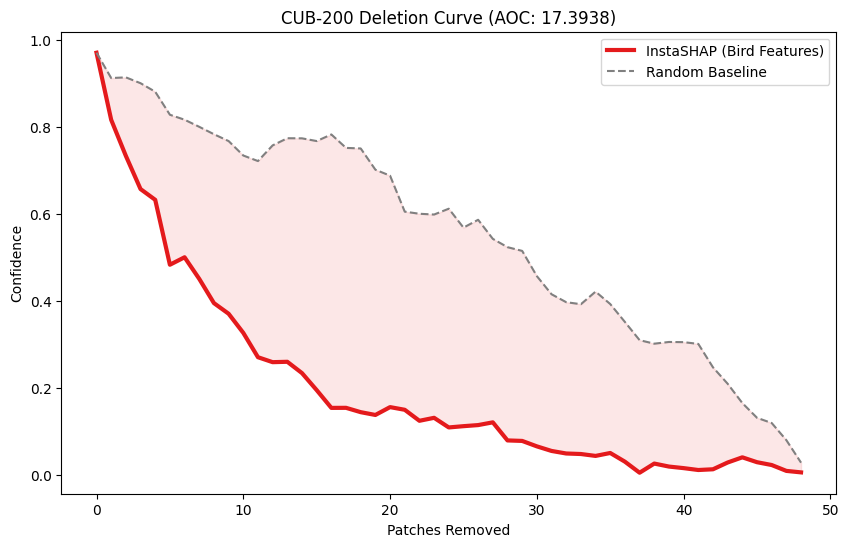

In [6]:
import torch.nn.functional as F
import numpy as np
import matplotlib.pyplot as plt
import random


def get_deletion_curve(model, img_tensor, heatmap, steps=49):
    """Deletes patches based on InstaSHAP importance."""
    model.eval()
    flat_shap = heatmap.flatten()
    indices = np.argsort(-flat_shap) # Sort most important first
    
    confidences = []
    temp_img = img_tensor.clone()
    
    # Get initial target class
    with torch.no_grad():
        mask = torch.ones((1, 49)).to(img_tensor.device)
        target_class = torch.argmax(model(temp_img, mask), dim=1).item()
    
    for i in range(steps):
        with torch.no_grad():
            mask = torch.ones((1, 49)).to(img_tensor.device)
            probs = F.softmax(model(temp_img, mask), dim=1)
            confidences.append(probs[0, target_class].item())
        
        # Delete patch (set to 0)
        idx = indices[i]
        row, col = divmod(idx, 7)
        r_start, c_start = row * 32, col * 32
        temp_img[0, :, r_start:r_start+32, c_start:c_start+32] = 0
        
    return confidences

def get_random_deletion_curve(model, img_tensor, steps=49):
    """Deletes patches in a random order."""
    model.eval()
    indices = list(range(49))
    random.shuffle(indices)
    
    confidences = []
    temp_img = img_tensor.clone()
    
    with torch.no_grad():
        mask = torch.ones((1, 49)).to(img_tensor.device)
        target_class = torch.argmax(model(temp_img, mask), dim=1).item()
    
    for i in range(steps):
        with torch.no_grad():
            mask = torch.ones((1, 49)).to(img_tensor.device)
            probs = F.softmax(model(temp_img, mask), dim=1)
            confidences.append(probs[0, target_class].item())
        
        idx = indices[i]
        row, col = divmod(idx, 7)
        r_start, c_start = row * 32, col * 32
        temp_img[0, :, r_start:r_start+32, c_start:c_start+32] = 0
        
    return confidences


def run_cub_deletion():
    model.eval()
    instashap_curves = []
    random_curves = []
    
    # We'll test 50 images for a smoother average
    test_indices = list(range(min(50, len(test_set))))
    
    print(">>> Running Deletion Benchmark for CUB-200...")
    for idx in test_indices:
        img_t, label = test_set[idx]
        img_t = img_t.unsqueeze(0).to(device)
        
        with torch.no_grad():
            feat = model.backbone(img_t)
            pts = feat.view(1, 2048, 49).permute(0, 2, 1)
            m_out = model.head(pts)
            
            # Use predicted class for the heatmap
            pred_idx = torch.argmax(m_out.sum(dim=1)).item()
            heatmap = m_out[0, :, pred_idx].view(7, 7).cpu().numpy()
            
            # 1. Get InstaSHAP Curve
            instashap_curves.append(get_deletion_curve(model, img_t, heatmap))
            # 2. Get Random Curve
            random_curves.append(get_random_deletion_curve(model, img_t))

    avg_insta = np.mean(instashap_curves, axis=0)
    avg_rand = np.mean(random_curves, axis=0)
    
    # Calculate AOC (Area Over Curve)
    # Using np.trapezoid to avoid the DeprecationWarning
    aoc_score = np.trapezoid(avg_rand) - np.trapezoid(avg_insta)
    
    plt.figure(figsize=(10, 6))
    plt.plot(avg_insta, label='InstaSHAP (Bird Features)', color='#e41a1c', linewidth=3)
    plt.plot(avg_rand, label='Random Baseline', color='gray', linestyle='--')
    plt.fill_between(range(49), avg_insta, avg_rand, color='#e41a1c', alpha=0.1)
    plt.title(f'CUB-200 Deletion Curve (AOC: {aoc_score:.4f})')
    plt.xlabel('Patches Removed')
    plt.ylabel('Confidence')
    plt.legend()
    plt.show()
    
    return aoc_score

cub_aoc = run_cub_deletion()

>>> Searching for misclassified birds...


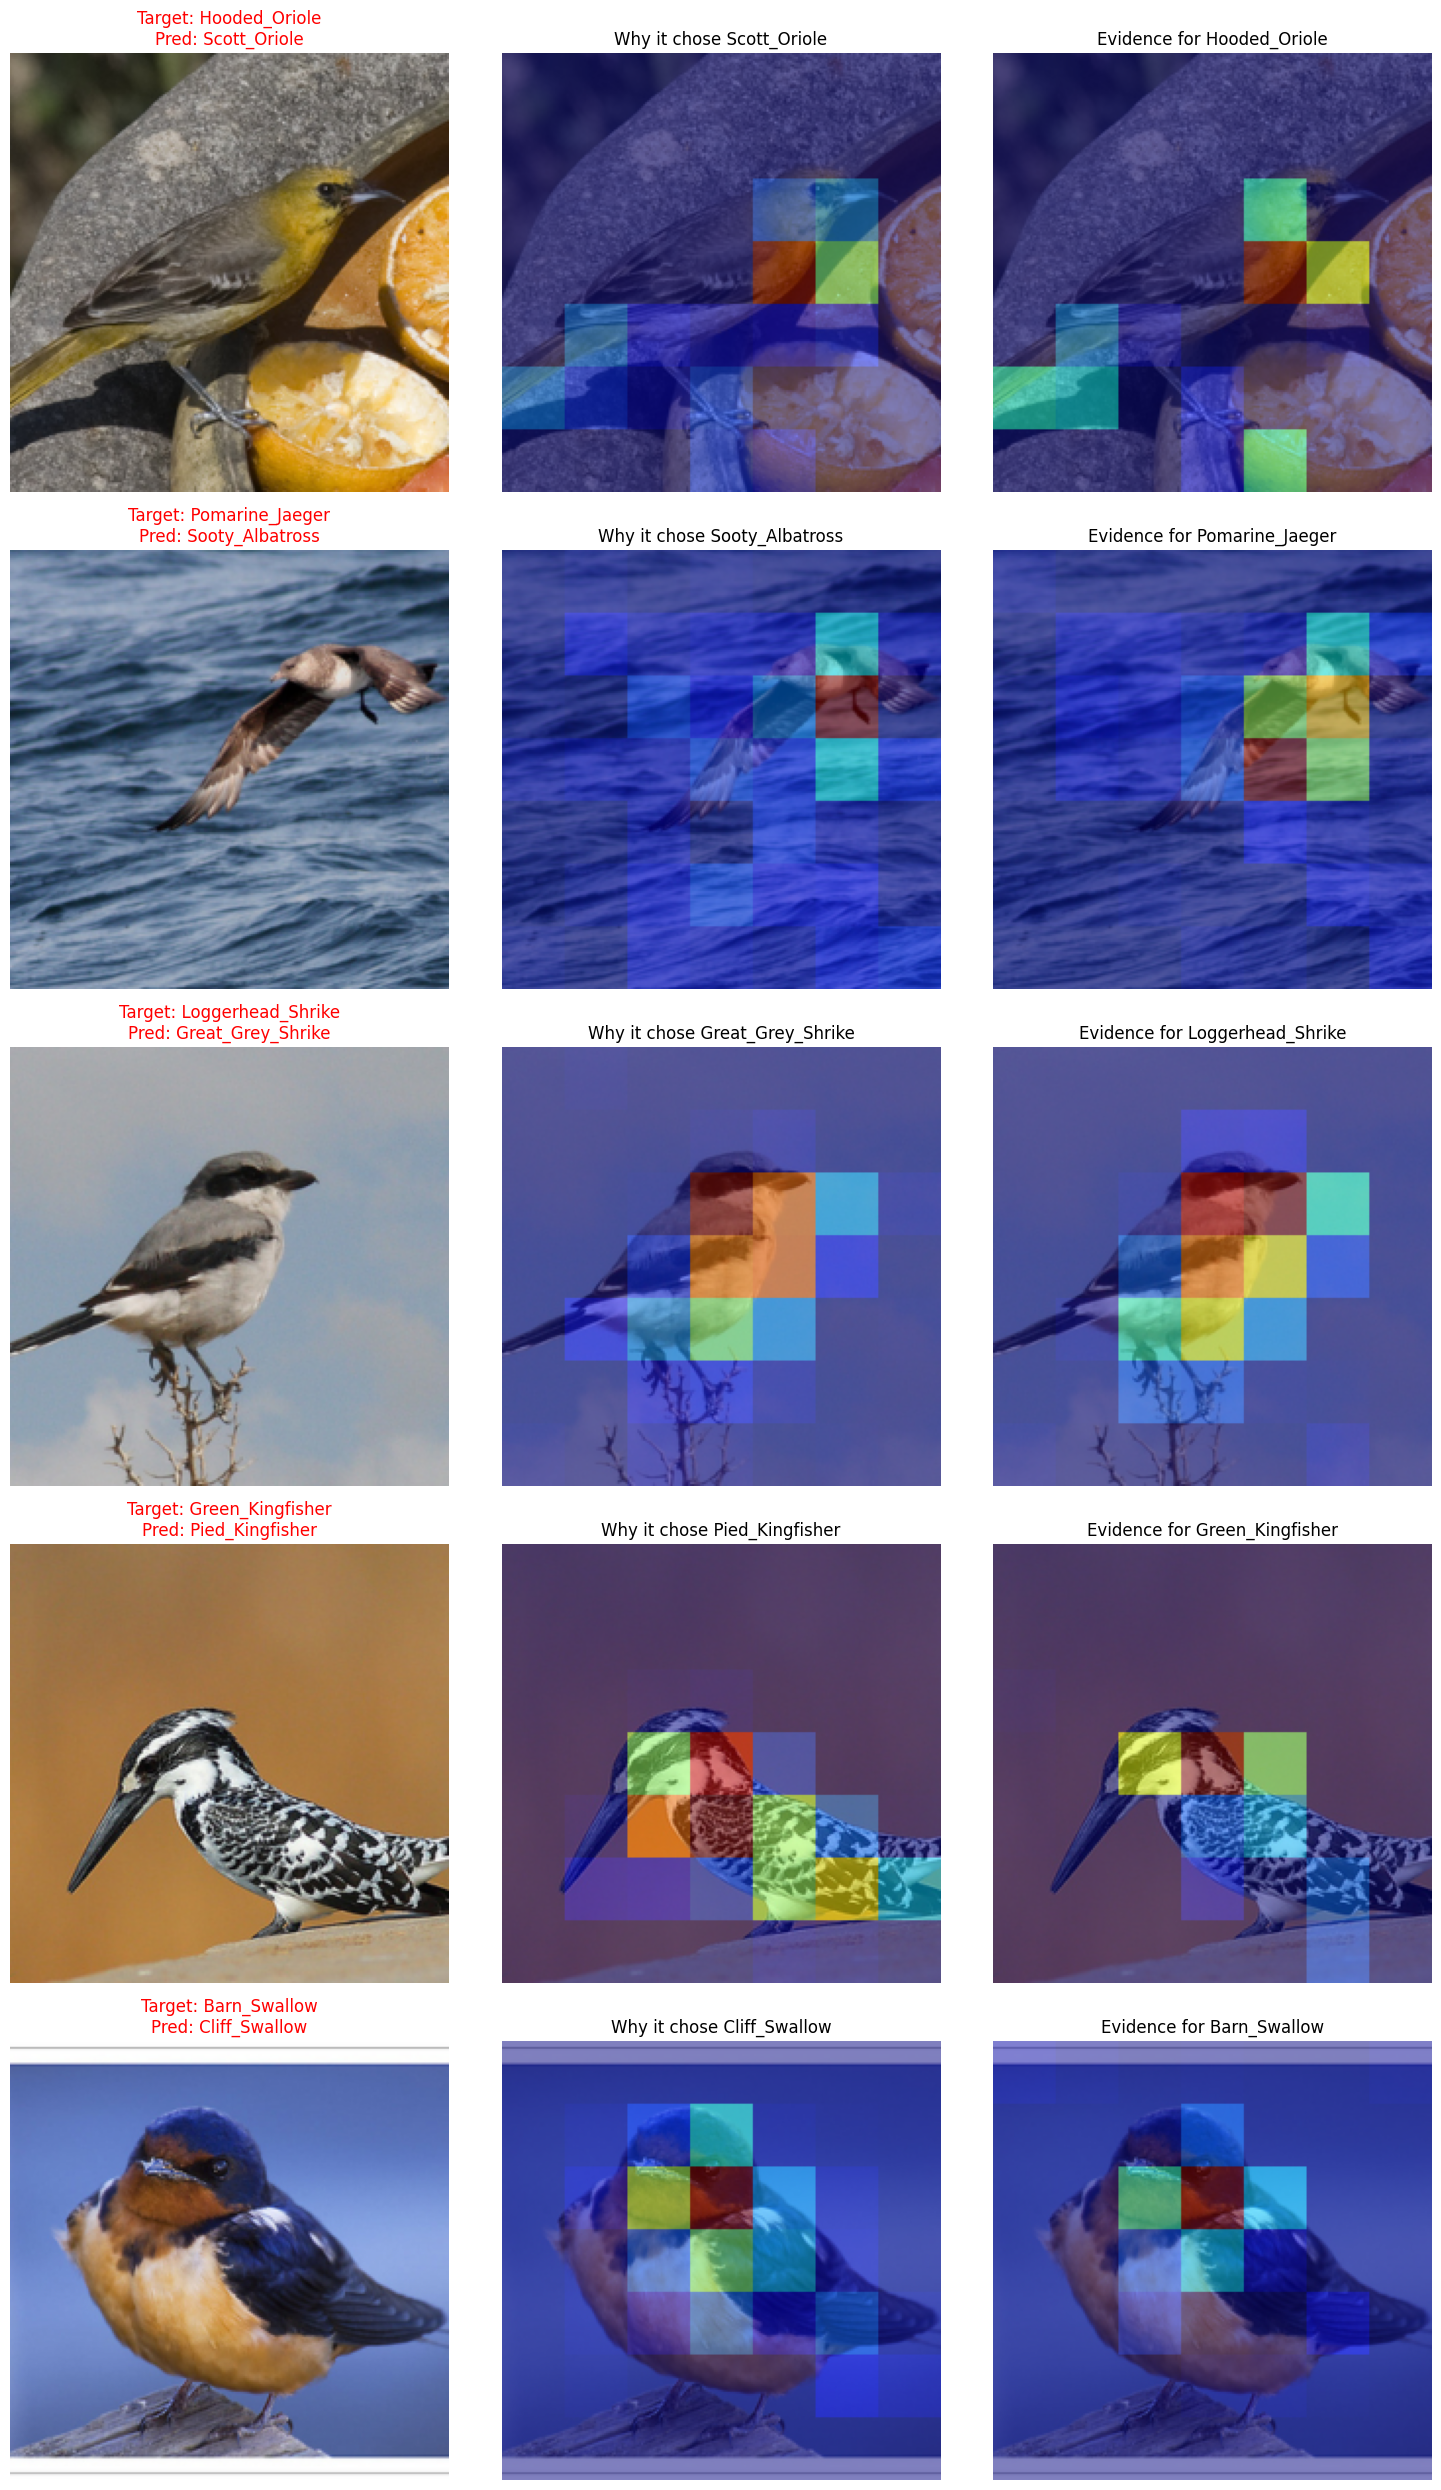

In [8]:
import matplotlib.pyplot as plt
import cv2
import numpy as np

def get_original_image(tensor):
    """
    Reverses ImageNet normalization so the image can be viewed by humans.
    Standard ImageNet normalization: Mean=[0.485, 0.456, 0.406], Std=[0.229, 0.224, 0.225]
    """
    # 1. Move to CPU and detach from the graph
    img = tensor.detach().cpu()
    
    # 2. Define the inverse mean and std
    mean = torch.tensor([0.485, 0.456, 0.406]).view(3, 1, 1)
    std = torch.tensor([0.229, 0.224, 0.225]).view(3, 1, 1)
    
    # 3. Denormalize: (image * std) + mean
    img = img * std + mean
    
    # 4. Clip to [0, 1] range and change shape from [C, H, W] to [H, W, C]
    img = img.clamp(0, 1).permute(1, 2, 0).numpy()
    
    return img

def visualize_bird_errors(model, dataset, num_samples=5):
    model.eval()
    error_indices = []
    
    # Search for incorrect predictions in the test set
    print(">>> Searching for misclassified birds...")
    for i in range(len(dataset)):
        img_t, label = dataset[i]
        img_t = img_t.unsqueeze(0).to(device)
        
        with torch.no_grad():
            mask = torch.ones((1, 49)).to(device)
            output = model(img_t, mask)
            pred = torch.argmax(output, dim=1).item()
            
            if pred != label:
                error_indices.append((i, label, pred))
        
        if len(error_indices) >= num_samples:
            break

    fig, axes = plt.subplots(len(error_indices), 3, figsize=(15, 5 * len(error_indices)))
    
    for i, (idx, true_idx, pred_idx) in enumerate(error_indices):
        img_t, _ = dataset[idx]
        img_t = img_t.unsqueeze(0).to(device)
        
        with torch.no_grad():
            feat = model.backbone(img_t)
            pts = feat.view(1, 2048, 49).permute(0, 2, 1)
            m_out = model.head(pts) # [1, 49, 200]
            
            # Heatmap for the WRONG prediction (Rank 1)
            hm_pred = m_out[0, :, pred_idx].view(7, 7).cpu().numpy()
            hm_pred = np.maximum(hm_pred, 0)
            if hm_pred.max() > 0: hm_pred /= hm_pred.max()
            
            # Heatmap for the TRUE class
            hm_true = m_out[0, :, true_idx].view(7, 7).cpu().numpy()
            hm_true = np.maximum(hm_true, 0)
            if hm_true.max() > 0: hm_true /= hm_true.max()

        orig = get_original_image(img_t[0])
        class_names = dataset.dataset.classes
        
        # Col 1: Original
        axes[i, 0].imshow(orig)
        axes[i, 0].set_title(f"Target: {class_names[true_idx].split('.')[-1]}\nPred: {class_names[pred_idx].split('.')[-1]}", color='red')
        axes[i, 0].axis('off')
        
        # Col 2: Heatmap for Predicted (Mistake)
        axes[i, 1].imshow(orig)
        res_pred = cv2.resize(hm_pred, (224, 224), interpolation=cv2.INTER_NEAREST)
        axes[i, 1].imshow(res_pred, cmap='jet', alpha=0.5)
        axes[i, 1].set_title(f"Why it chose {class_names[pred_idx].split('.')[-1]}")
        axes[i, 1].axis('off')
        
        # Col 3: Heatmap for True Class
        axes[i, 2].imshow(orig)
        res_true = cv2.resize(hm_true, (224, 224), interpolation=cv2.INTER_NEAREST)
        axes[i, 2].imshow(res_true, cmap='jet', alpha=0.5)
        axes[i, 2].set_title(f"Evidence for {class_names[true_idx].split('.')[-1]}")
        axes[i, 2].axis('off')

    plt.tight_layout()
    plt.show()

visualize_bird_errors(model, test_set)